# Notebook 19: Strategy Comparison

Interpretation and plots for the four momentum strategies (core, satellite, blend,
core_volsized) backtested over rolling 5-week windows, 2016-2026 US equities.
Reads the backtest outputs; all strategy logic lives in *strategies/*. The question:
how do the four trade off return against risk, and does concentration or
volatility-sizing earn its place?

In [1]:
import os
os.chdir("..")                      # notebooks/ -> repo root, so cache paths resolve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = "data/equity_cache"
nonover = pd.read_parquet(f"{CACHE}/backtest_nonoverlap.parquet")
over = pd.read_parquet(f"{CACHE}/backtest_overlap.parquet")

STRATS = ["core", "satellite", "blend", "core_volsized"]
COLORS = {"core": "C0", "satellite": "C3", "blend": "C2", "core_volsized": "C4"}

def tail(returns, a=0.05):
    q = returns.quantile(a)
    return -q, -returns[returns <= q].mean()     # VaR, CVaR as positive losses

# per-strategy stats table from the non-overlapping (primary) view
rows = []
for s in STRATS:
    r = nonover[nonover.strategy == s]["total_return"]
    var, cvar = tail(r)
    rows.append({"strategy": s, "mean": r.mean(), "std": r.std(),
                 "median": r.median(), "VaR5": var, "CVaR5": cvar,
                 "sharpe_like": r.mean() / r.std()})
stats = pd.DataFrame(rows).set_index("strategy")
print(stats.round(3).to_string())

                mean    std  median   VaR5  CVaR5  sharpe_like
strategy                                                      
core           0.043  0.108   0.043  0.128  0.156        0.400
satellite      0.047  0.170   0.026  0.178  0.213        0.276
blend          0.044  0.115   0.039  0.132  0.158        0.384
core_volsized  0.035  0.089   0.037  0.119  0.152        0.390


## 1. Risk-return frontier

The key figure. Each strategy is a point: return up, risk right. If the points lie
on a line, the strategies are the same frontier at different risk levels (no free
lunch); a point sitting above the line would be genuinely better risk-adjusted.

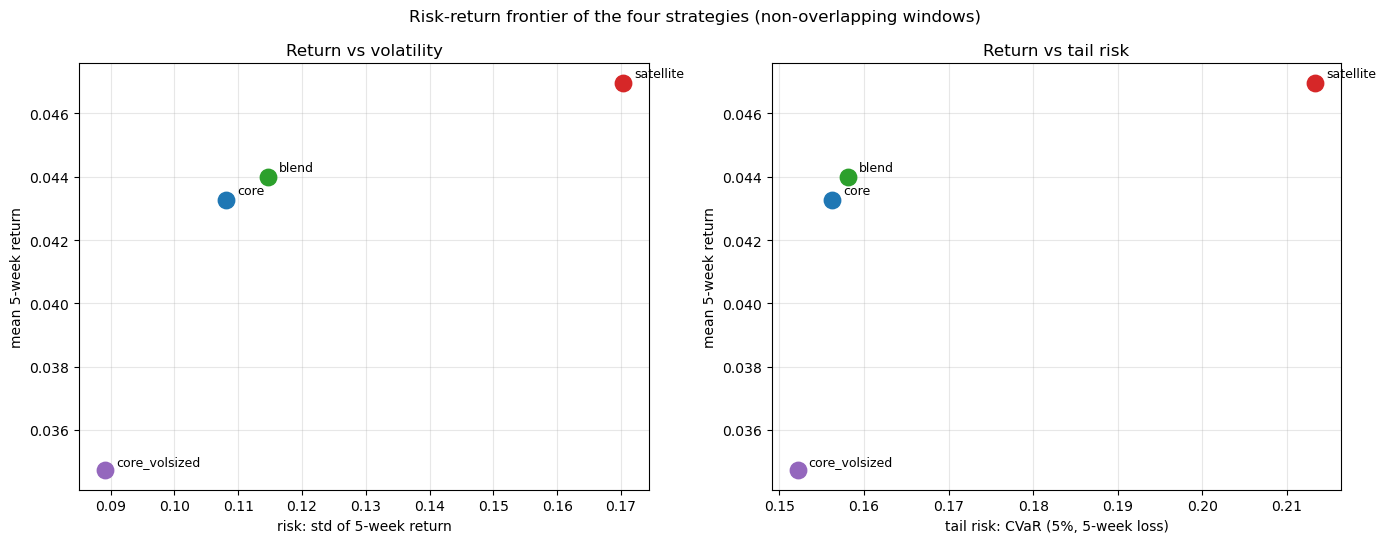

In [2]:
fig, (axS, axC) = plt.subplots(1, 2, figsize=(14, 5.5))

for s in STRATS:
    axS.scatter(stats.loc[s, "std"], stats.loc[s, "mean"],
                s=140, color=COLORS[s], zorder=5)
    axS.annotate(s, (stats.loc[s, "std"], stats.loc[s, "mean"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
axS.set_xlabel("risk: std of 5-week return")
axS.set_ylabel("mean 5-week return")
axS.set_title("Return vs volatility")
axS.grid(alpha=0.3)

for s in STRATS:
    axC.scatter(stats.loc[s, "CVaR5"], stats.loc[s, "mean"],
                s=140, color=COLORS[s], zorder=5)
    axC.annotate(s, (stats.loc[s, "CVaR5"], stats.loc[s, "mean"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)
axC.set_xlabel("tail risk: CVaR (5%, 5-week loss)")
axC.set_ylabel("mean 5-week return")
axC.set_title("Return vs tail risk")
axC.grid(alpha=0.3)

fig.suptitle("Risk-return frontier of the four strategies (non-overlapping windows)")
fig.tight_layout()
plt.show()

### Reading

Interpret from the plot: are the four roughly collinear (same frontier, different
points, meaning no strategy dominates on risk-adjusted terms), and where does each
sit? Expect core_volsized bottom-left (least risk, least return), satellite far
right (most risk, worst tail), core and blend clustered in between. The sharpe_like
column in Cell 2 quantifies it: near-equal ratios confirm collinearity. Nothing sits meaningfully above the line, so no strategy dominates on risk-adjusted terms, which is exactly the DeMiguel-Garlappi-Uppal result: the fancy weighting did not buy you a free lunch, it just moved you along the frontier.

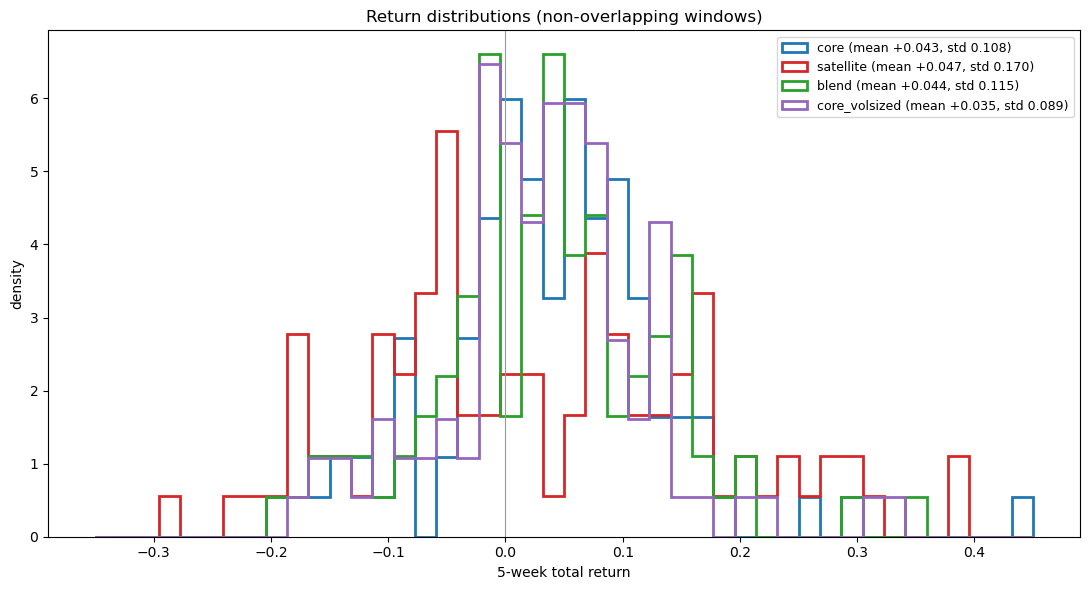

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
bins = np.linspace(-0.35, 0.45, 45)
for s in STRATS:
    r = nonover[nonover.strategy == s]["total_return"]
    ax.hist(r, bins=bins, histtype="step", lw=2, color=COLORS[s],
            density=True, label=f"{s} (mean {r.mean():+.3f}, std {r.std():.3f})")
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel("5-week total return")
ax.set_ylabel("density")
ax.set_title("Return distributions (non-overlapping windows)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

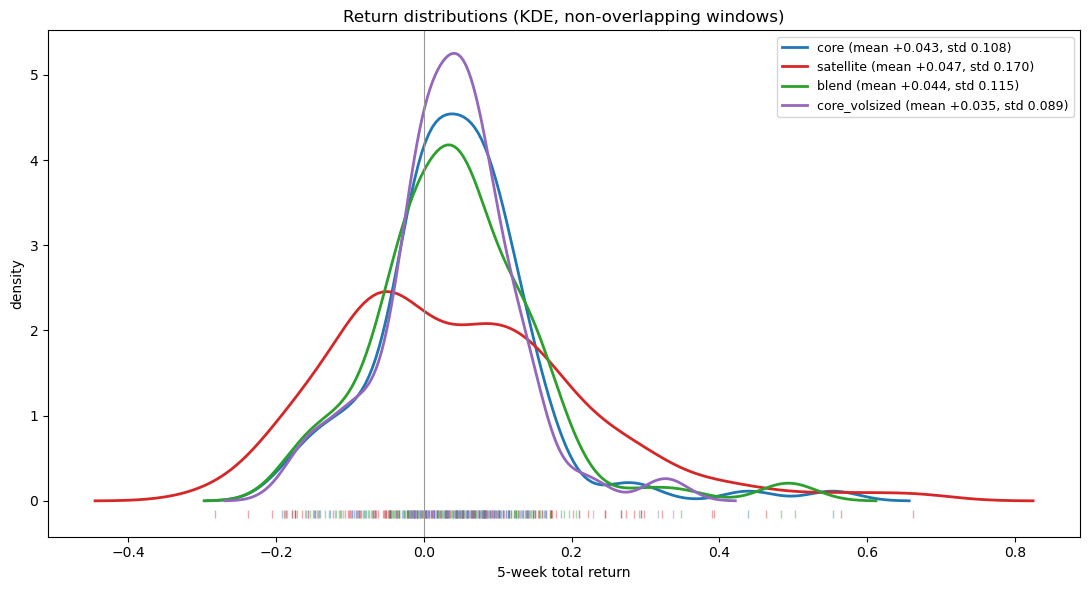

In [4]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 6))
for s in STRATS:
    r = nonover[nonover.strategy == s]["total_return"]
    sns.kdeplot(r, ax=ax, color=COLORS[s], lw=2, fill=False,
                bw_adjust=0.8,     # slightly tighter than default so the tail isn't over-smoothed
                label=f"{s} (mean {r.mean():+.3f}, std {r.std():.3f})")
    # rug: the actual window outcomes, so the honest tail is visible under the smooth curve
    ax.plot(r, np.full_like(r, -0.15), "|", color=COLORS[s], alpha=0.4, markersize=6)
ax.axvline(0, color="0.6", lw=0.8)
ax.set_xlabel("5-week total return")
ax.set_ylabel("density")
ax.set_title("Return distributions (KDE, non-overlapping windows)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

### Reading

Shape tells the story words cannot: core and core_volsized tall and narrow (returns
cluster), satellite short and wide with a heavier left tail (concentration widens
both tails but the left one is what hurts). The satellite's mean sits right of its
median because a few big right-tail windows drag the average up while the typical
window is worse, the positive-skew-on-a-worse-median signature of concentration.

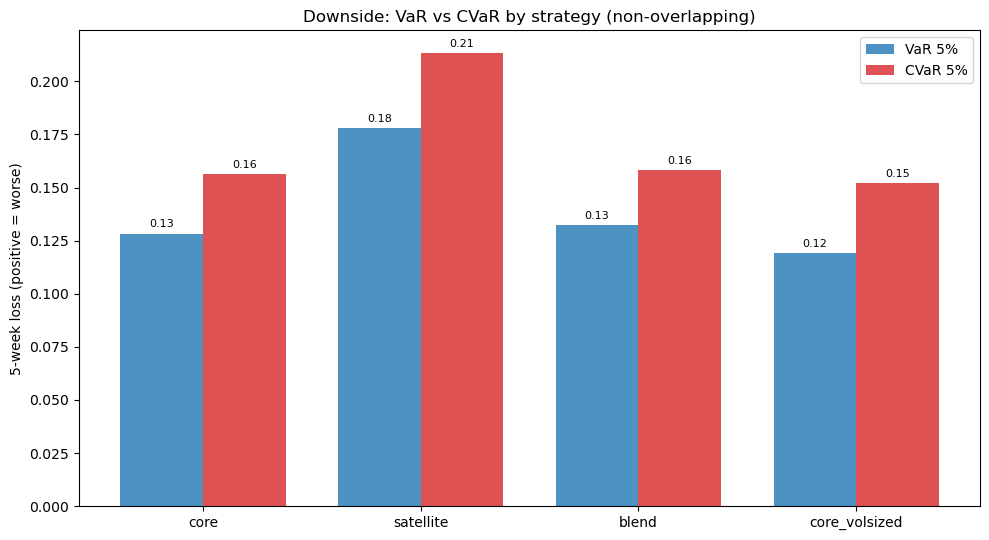

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(STRATS))
w = 0.38
var5 = [stats.loc[s, "VaR5"] for s in STRATS]
cvar5 = [stats.loc[s, "CVaR5"] for s in STRATS]
ax.bar(x - w/2, var5, w, label="VaR 5%", color="C0", alpha=0.8)
ax.bar(x + w/2, cvar5, w, label="CVaR 5%", color="C3", alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(STRATS)
ax.set_ylabel("5-week loss (positive = worse)")
ax.set_title("Downside: VaR vs CVaR by strategy (non-overlapping)")
ax.legend()
for i, (v, c) in enumerate(zip(var5, cvar5)):
    ax.text(i - w/2, v + 0.003, f"{v:.2f}", ha="center", fontsize=8)
    ax.text(i + w/2, c + 0.003, f"{c:.2f}", ha="center", fontsize=8)
fig.tight_layout()
plt.show()

### Reading

CVaR sits above VaR for every strategy (the tail's average is worse than its
threshold, always). The satellite's gap between the two is the widest, meaning when
it breaches the bad threshold it goes deep. core_volsized has the lowest tail
metrics, confirming inverse-vol weighting compressed the downside, but recall from
Cell 2 it also lowered the mean, so the risk-adjusted ratio barely changed.